In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
Path to dataset files: /kaggle/input/coco-2017-dataset


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])  # print first 5 only
    print("-" * 50)

Folder: /kaggle/input/coco-2017-dataset
Subfolders: ['coco2017']
Files: []
--------------------------------------------------
Folder: /kaggle/input/coco-2017-dataset/coco2017
Subfolders: ['val2017', 'annotations', 'test2017', 'train2017']
Files: []
--------------------------------------------------
Folder: /kaggle/input/coco-2017-dataset/coco2017/val2017
Subfolders: []
Files: ['000000011197.jpg', '000000219485.jpg', '000000151000.jpg', '000000371677.jpg', '000000038825.jpg']
--------------------------------------------------
Folder: /kaggle/input/coco-2017-dataset/coco2017/annotations
Subfolders: []
Files: ['person_keypoints_train2017.json', 'instances_val2017.json', 'instances_train2017.json', 'person_keypoints_val2017.json', 'captions_train2017.json']
--------------------------------------------------
Folder: /kaggle/input/coco-2017-dataset/coco2017/test2017
Subfolders: []
Files: ['000000355443.jpg', '000000081349.jpg', '000000436639.jpg', '000000210548.jpg', '000000196829.jpg']
----

In [ ]:
!pip install pycocotools
!pip install opencv-python
!pip install matplotlib

In [ ]:
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
import os

ann_file = os.path.join(path, "coco2017", "annotations", "instances_train2017.json")
coco = COCO(ann_file)

loading annotations into memory...
Done (t=19.62s)
creating index...
index created!


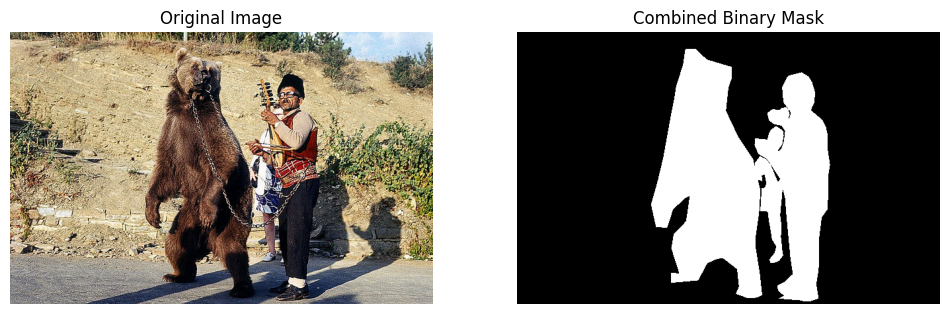

In [ ]:
# Get all image IDs
img_ids = coco.getImgIds()

# Select random image
img_id = random.choice(img_ids)

# Load image info
img_info = coco.loadImgs(img_id)[0]
img_path = os.path.join(path, "coco2017", "train2017", img_info['file_name'])

# Read image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get annotation IDs for this image
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

# Create empty mask
mask = np.zeros((img_info['height'], img_info['width']))

# Merge all instance masks into single binary mask
for ann in anns:
    mask += coco.annToMask(ann)

# Convert to binary (0 or 1)
mask = np.clip(mask, 0, 1)

# Show image and mask
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Combined Binary Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.show()

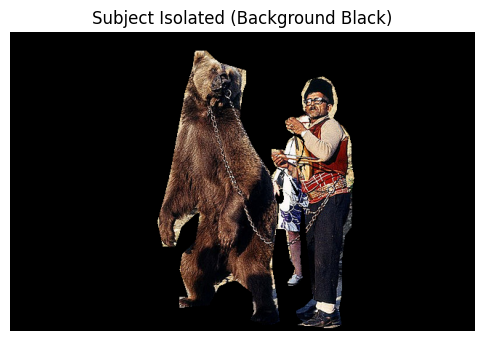

In [ ]:
# Expand mask to 3 channels
mask_3ch = np.stack([mask]*3, axis=-1)

# Apply mask
isolated = image * mask_3ch

plt.figure(figsize=(6,6))
plt.title("Subject Isolated (Background Black)")
plt.imshow(isolated.astype(np.uint8))
plt.axis("off")
plt.show()

In [ ]:
!pip install pycocotools
!pip install albumentations
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.9 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
def get_train_transforms():
    return A.Compose([
        A.Resize(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(),
        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(256, 256),
        A.Normalize(),
        ToTensorV2()
    ])

In [ ]:
from torch.utils.data import Dataset
from pycocotools.coco import COCO
import cv2
import numpy as np
import os

class COCOSegmentationDataset(Dataset):
    def __init__(self, images_dir, annotation_file, transforms=None):
        self.images_dir = images_dir
        self.coco = COCO(annotation_file)
        self.image_ids = self.coco.getImgIds()
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):

        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]

        img_path = os.path.join(self.images_dir, img_info['file_name'])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = np.zeros((img_info['height'], img_info['width']))

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        for ann in anns:
            mask += self.coco.annToMask(ann)

        mask = np.clip(mask, 0, 1).astype(np.float32)

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0)

        return image, mask

In [ ]:
class COCOSegmentationDataset(Dataset):
    def __init__(self, images_dir, annotation_file, transforms=None):
        self.images_dir = images_dir
        self.coco = COCO(annotation_file)
        self.image_ids = self.coco.getImgIds()
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.images_dir, img_info['file_name'])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Create empty mask
        mask = np.zeros((img_info['height'], img_info['width']))

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        for ann in anns:
            mask += self.coco.annToMask(ann)

        mask = np.clip(mask, 0, 1).astype(np.float32)

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # Add channel dimension to mask
        mask = mask.unsqueeze(0)

        return image, mask

In [ ]:
import os
from torch.utils.data import DataLoader

path = "/kaggle/input/coco-2017-dataset"

train_images = os.path.join(path, "coco2017", "train2017")
val_images = os.path.join(path, "coco2017", "val2017")

train_ann = os.path.join(path, "coco2017", "annotations", "instances_train2017.json")
val_ann = os.path.join(path, "coco2017", "annotations", "instances_val2017.json")

train_dataset = COCOSegmentationDataset(
    train_images,
    train_ann,
    transforms=get_train_transforms()
)

val_dataset = COCOSegmentationDataset(
    val_images,
    val_ann,
    transforms=get_val_transforms()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

loading annotations into memory...
Done (t=19.47s)
creating index...
index created!
loading annotations into memory...
Done (t=0.82s)
creating index...
index created!


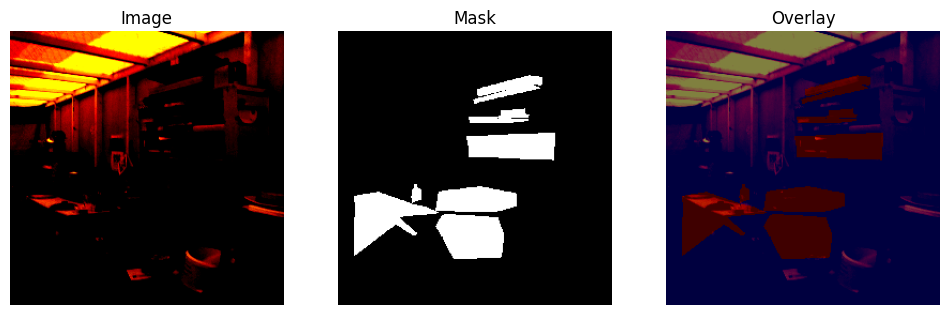

In [ ]:
import matplotlib.pyplot as plt

image, mask = train_dataset[10]

image_np = image.permute(1,2,0).numpy()
mask_np = mask.squeeze().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image_np)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask_np, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(image_np)
plt.imshow(mask_np, alpha=0.5, cmap='jet')
plt.axis("off")

plt.show()